In [25]:
import numpy as np
import re
from typing import Dict, List
import matplotlib.pylab as plt
from pyiron_atomistics import Project
import ase.units as units
import pandas
import ase.units as units
from lammps import lammps

In [26]:
# 1. Compile once: match an element symbol ([A-Z][a-z]*)
#    followed by an optional integer count (\d*)  
#    — missing digits will yield an empty string  
ELEMENT = re.compile(r'([A-Z][a-z]*)(\d*)')


def extract_composition(composition: str) -> dict[str, float]:
    '''
    Function written to extract the fraction of each elemet from a given composition.
    The composition can be given as a fraction or in mol%, and the function will return 
    the molar fraction in all cases
    Example of usage: extract_composition("0.25CaO-0.25Al2O3-0.5SiO2")
                      extract_composition("79SiO2-13B2O3-3Al2O3-4Na2O-1K2O")

    Example of an output:
    print(extract_composition("0.25CaO-0.25Al2O3-0.5SiO2"))
    Output: {'CaO': 0.25, 'Al2O3': 0.25, 'SiO2': 0.5}
    '''
    comp_dict = {}
    total = 0.0
    for segment in composition.split('-'):
        # Find the index of the first letter
        idx = next(i for i, ch in enumerate(segment) if ch.isalpha())
        frac_str, oxide = segment[:idx], segment[idx:]
        frac = float(frac_str) if frac_str else 1.0
        if frac > 1.0:
            frac = frac / 100
        comp_dict[oxide] = frac
        total += frac
    if round(total, 2) < 1.0:
        raise ValueError(f"Component sum ({total:.2f}) is less than 1.00")
    return comp_dict


def parse_formula(formula: str) -> Dict[str, int]:
    """
    Parse a chemical formula (e.g. "Al2O3") and return
    a dict of element counts: {"Al": 2, "O": 3}.
    """
    counts: Dict[str, int] = {}
    for elem, cnt_str in ELEMENT.findall(formula):
        # Default to 1 if no digits were captured 
        cnt = int(cnt_str) if cnt_str else 1  
        counts[elem] = counts.get(elem, 0) + cnt
    return counts

def extract_stoichiometry(composition: str) -> Dict[str, Dict[str, int]]:
    """
    Given a composition string, return a mapping:
        { oxide_formula: { element: count, ... }, ... }
    Uses extract_composition() to isolate formulas first.
    """
    comp_dict = extract_composition(composition)
    stoichiometry: Dict[str, Dict[str, int]] = {}
    for oxide in comp_dict:
        stoichiometry[oxide] = parse_formula(oxide)
    return stoichiometry



def create_random_atoms(
    composition: str,
    n_molecules: int,
    box_length: float = 50.0,
    min_distance: float = 1.6,
    seed: int = 42,
    max_attempts_per_atom: int = 100000,
):
    '''
    Generate random atom positions in a cubic box, according to a given composition.

    - composition: e.g. "0.25CaO-0.25Al2O3-0.5SiO2"
    - n_molecules: total number of molecules to define atom counts
    - box_length: size of cubic box (calculate automatically from density of provided manually)
    - min_distance: minimum distance between any two atoms the default value should be fine in general.
    - seed: random seed for reproducibility
    - max_attempts_per_atom: fallback for dense packing 100000 is a good value that should be enough in most cases. 

    Returns:
        atoms: list of {"element": str, "position": [x,y,z]}
        atom_counts: dict of total counts per element
    '''
    np.random.seed(seed)

    # 1. Determine total atom counts
    comp_dict = extract_composition(composition)
    molecule_counts = {ox: round(frac * n_molecules) for ox, frac in comp_dict.items()}
    # adjust rounding error
    diff = n_molecules - sum(molecule_counts.values())
    if diff:
        main = max(comp_dict, key=comp_dict.get)
        molecule_counts[main] += diff

    # compute per-element counts
    atom_counts = {}
    for ox, mol_cnt in molecule_counts.items():
        stoich = STOICHIOMETRY.get(ox)
        if stoich is None:
            raise KeyError(f"Unknown oxide formula: {ox}")
        for elem, num in stoich.items():
            atom_counts[elem] = atom_counts.get(elem, 0) + num * mol_cnt

    # 2. Place atoms with min distance
    atoms = []
    positions = []

    for elem, count in atom_counts.items():
        placed = 0
        attempts = 0
        while placed < count:
            if attempts >= max_attempts_per_atom:
                raise RuntimeError(
                    f"Failed to place {elem} atoms: increase box or reduce min_distance"
                )
            pos = np.random.uniform(0, box_length, size=3)
            if all(np.linalg.norm(pos - p) >= min_distance for p in positions):
                atoms.append({"element": elem, "position": pos.tolist()})
                positions.append(pos)
                placed += 1
                attempts = 0
            else:
                attempts += 1

    return atoms, atom_counts



def write_lammps_data(
    atoms: list[dict],
    box_length: float,
    filename: str
):
    '''
    Write a LAMMPS data file from atom list.

    Parameters:
        atoms: list of {"element": str, "position": [x,y,z]}
        box_length: size of the cubic box
        filename: output filepath
    '''
    n_atoms = len(atoms)
    elements = sorted(set(atom['element'] for atom in atoms))
    element_to_type = {elem: i+1 for i, elem in enumerate(elements)}  # e.g., {'Al':1, 'Ca':2, 'Na':3, 'O':4, 'Si':5}
    n_types = len(element_to_type)

    with open(filename, 'w') as f:
        # Header
        f.write("LAMMPS data file via create_random_atoms and write_lammps_data\n\n")
        f.write(f"{n_atoms} atoms\n")
        f.write(f"{n_types} atom types\n\n")
        # Box dims
        f.write(f"0.0 {box_length} xlo xhi\n")
        f.write(f"0.0 {box_length} ylo yhi\n")
        f.write(f"0.0 {box_length} zlo zhi\n\n")
        
        # Masses section
        f.write("Masses\n\n")
        for elem, type_id in element_to_type.items():
            mass = ATOMIC_MASSES[elem]  # You can later replace with real atomic masses if needed
            f.write(f"{type_id} {mass} # {elem}\n")
        
        f.write("\nAtoms\n\n")
        
        # Atoms section
        for i, atom in enumerate(atoms, start=1):
            elem = atom['element']
            type_id = element_to_type[elem]
            x, y, z = atom['position']
            q = 0.0  # Charge, I put 0 for simplicity. the real value should be set by the potential parameters either in LAMMPS or in pyrion
            # it can also be calculated automatically here if needed but the potential model should be specified in advance.
            # I wanted to keep these function as general as possible.
            f.write(f"{i} {type_id} {q:.6f} {x:.6f} {y:.6f} {z:.6f}\n")
    return element_to_type


def get_box_from_density(
    composition: str,
    n_molecules: int,
    density: float = 2.65
) -> float:
    """
    Calculate the cubic box length in angstroms needed for a given composition,
    number of molecules, and target density (g/cm^3).
    very straightforward function that calculates the box length from the density
    and the number of molecules.

    Steps:
      1. Parse composition into oxide fractions.
      2. Compute molecule counts and adjust rounding discrepancies.
      3. Tally per-element atom counts via STOICHIOMETRY.
      4. Compute total mass (g) using ATOMIC_MASSES and AVOGADRO.
      5. Derive volume (cm3) from mass/density, convert to angstrom3,
         and return cube root for box length.
    """
    # 1. Determine molecule counts
    comp_dict = extract_composition(composition)
    molecule_counts = {ox: round(frac * n_molecules)
                       for ox, frac in comp_dict.items()}
    # Adjust rounding error
    diff = n_molecules - sum(molecule_counts.values())
    if diff:
        main = max(comp_dict, key=comp_dict.get)
        molecule_counts[main] += diff

    # 2. Compute per-element atom counts
    atom_counts: dict[str, int] = {}
    for oxide, mol_cnt in molecule_counts.items():
        stoich = STOICHIOMETRY[oxide]
        for elem, num in stoich.items():
            atom_counts[elem] = atom_counts.get(elem, 0) + num * mol_cnt

    # 3. Total mass in grams
    #    (sum of atom_counts × atomic_mass) / Avogadro
    total_mass_g = sum(
        atom_counts[el] * ATOMIC_MASSES[el] for el in atom_counts
    ) / AVOGADRO

    # 4. Compute volume (cm3) and convert to \AA3 (1 cm3 = 1e24 \AA3)
    volume_cm3 = total_mass_g / density
    volume_A3 = volume_cm3 * 1e24

    # 5. Box length in \AA
    box_length_A = volume_A3 ** (1/3)
    return box_length_A


comp = "25CaO-25Al2O3-50SiO2-5Na2O"
STOICHIOMETRY = extract_stoichiometry(comp)


# Atomic masses of elements (g/mol)
# This is a dictionary of atomic masses for all periodic table common elements.
# it is an overkill for now but it is good to have it in case you need to add more elements.
ATOMIC_MASSES = {
    'H': 1.008,      # Hydrogen
    'He': 4.0026,    # Helium
    'Li': 6.94,      # Lithium
    'Be': 9.0122,    # Beryllium
    'B': 10.81,      # Boron
    'C': 12.011,     # Carbon
    'N': 14.007,     # Nitrogen
    'O': 15.999,     # Oxygen
    'F': 18.998,     # Fluorine
    'Ne': 20.180,    # Neon
    'Na': 22.990,    # Sodium
    'Mg': 24.305,    # Magnesium
    'Al': 26.982,    # Aluminum
    'Si': 28.085,    # Silicon
    'P': 30.974,     # Phosphorus
    'S': 32.06,      # Sulfur
    'Cl': 35.45,     # Chlorine
    'Ar': 39.948,    # Argon
    'K': 39.098,     # Potassium
    'Ca': 40.078,    # Calcium
    'Sc': 44.956,    # Scandium
    'Ti': 47.867,    # Titanium
    'V': 50.942,     # Vanadium
    'Cr': 51.996,    # Chromium
    'Mn': 54.938,    # Manganese
    'Fe': 55.845,    # Iron
    'Co': 58.933,    # Cobalt
    'Ni': 58.693,    # Nickel
    'Cu': 63.546,    # Copper
    'Zn': 65.38,     # Zinc
    'Ga': 69.723,    # Gallium
    'Ge': 72.630,    # Germanium
    'As': 74.922,    # Arsenic
    'Se': 78.971,    # Selenium
    'Br': 79.904,    # Bromine
    'Kr': 83.798,    # Krypton
    'Rb': 85.468,    # Rubidium
    'Sr': 87.62,     # Strontium
    'Y': 88.906,     # Yttrium
    'Zr': 91.224,    # Zirconium
    'Nb': 92.906,    # Niobium
    'Mo': 95.95,     # Molybdenum
    'Tc': 98.0,      # Technetium
    'Ru': 101.07,    # Ruthenium
    'Rh': 102.91,    # Rhodium
    'Pd': 106.42,    # Palladium
    'Ag': 107.87,    # Silver
    'Cd': 112.41,    # Cadmium
    'In': 114.82,    # Indium
    'Sn': 118.71,    # Tin
    'Sb': 121.76,    # Antimony
    'Te': 127.60,    # Tellurium
    'I': 126.90,     # Iodine
    'Xe': 131.29,    # Xenon
    'Cs': 132.91,    # Cesium
    'Ba': 137.33,    # Barium
    'La': 138.91,    # Lanthanum
    'Ce': 140.12,    # Cerium
    'Pr': 140.91,    # Praseodymium
    'Nd': 144.24,    # Neodymium
    'Pm': 145.0,     # Promethium
    'Sm': 150.36,    # Samarium
    'Eu': 151.96,    # Europium
    'Gd': 157.25,    # Gadolinium
    'Tb': 158.93,    # Terbium
    'Dy': 162.50,    # Dysprosium
    'Ho': 164.93,    # Holmium
    'Er': 167.26,    # Erbium
    'Tm': 168.93,    # Thulium
    'Yb': 173.05,    # Ytterbium
    'Lu': 174.97,    # Lutetium
    'Hf': 178.49,    # Hafnium
    'Ta': 180.95,    # Tantalum
    'W': 183.84,     # Tungsten
    'Re': 186.21,    # Rhenium
    'Os': 190.23,    # Osmium
    'Ir': 192.22,    # Iridium
    'Pt': 195.08,    # Platinum
    'Au': 196.97,    # Gold
    'Hg': 200.59,    # Mercury
    'Tl': 204.38,    # Thallium
    'Pb': 207.2,     # Lead
    'Bi': 208.98,    # Bismuth
    'Po': 209.0,     # Polonium
    'At': 210.0,     # Astatine
    'Rn': 222.0,     # Radon
    'Fr': 223.0,     # Francium
    'Ra': 226.0,     # Radium
    'Ac': 227.0,     # Actinium
    'Th': 232.04,    # Thorium
    'Pa': 231.04,    # Protactinium
    'U': 238.03,     # Uranium
    'Np': 237.0,     # Neptunium
    'Pu': 244.0,     # Plutonium
    'Am': 243.0,     # Americium
    'Cm': 247.0,     # Curium
    'Bk': 247.0,     # Berkelium
    'Cf': 251.0,     # Californium
    'Es': 252.0,     # Einsteinium
    'Fm': 257.0,     # Fermium
    'Md': 258.0,     # Mendelevium
    'No': 259.0,     # Nobelium
    'Lr': 266.0,     # Lawrencium
    'Rf': 267.0,     # Rutherfordium
    'Db': 268.0,     # Dubnium
    'Sg': 269.0,     # Seaborgium
    'Bh': 270.0,     # Bohrium
    'Hs': 277.0,     # Hassium
    'Mt': 278.0,     # Meitnerium
    'Ds': 281.0,     # Darmstadtium
    'Rg': 282.0,     # Roentgenium
    'Cn': 285.0,     # Copernicium
    'Nh': 286.0,     # Nihonium
    'Fl': 289.0,     # Flerovium
    'Mc': 290.0,     # Moscovium
    'Lv': 293.0,     # Livermorium
    'Ts': 294.0,     # Tennessine
    'Og': 294.0      # Oganesson
}


# Avogadro's number (mol-1)
AVOGADRO = 6.02214076e23

# Example usage
if __name__ == "__main__":
    comp = "0.25CaO-0.25Al2O3-0.50SiO2" # I used Anorthite as an example CaAl2Si2O8
    box_length = get_box_from_density(comp, n_molecules=100, density=2.96*1.0)
    atoms, counts = create_random_atoms(comp, 
                                        n_molecules=100, 
                                        box_length=box_length, 
                                        min_distance=1.6,
                                        max_attempts_per_atom = 10000)
    print(f"Total atoms: {sum(counts.values())}")  # should be 325
    print("Counts:", counts)
    print("First 5 atoms:", atoms[:5])
    print(box_length)
    types = write_lammps_data(atoms, box_length=box_length, filename="random_atoms.data")


Total atoms: 325
Counts: {'Ca': 25, 'O': 200, 'Al': 50, 'Si': 50}
First 5 atoms: [{'element': 'Ca', 'position': [5.896377301657387, 14.967075553689652, 11.523765402569454]}, {'element': 'Ca', 'position': [9.424668066340264, 2.456198211746539, 2.455818489415728]}, {'element': 'Ca', 'position': [0.9144090983919809, 13.636193048963609, 9.46334112841095]}, {'element': 'Ca', 'position': [11.14717186637118, 0.3240612656005735, 15.269270631252507]}, {'element': 'Ca', 'position': [13.105127181709669, 3.3428502033656575, 2.862466677305313]}]
15.742979202877747


In [27]:
print("Types:", types.get("O"))

Types: 3


In [28]:
# Adpted from a pyiron_atomistics example
# Parameters are taken from Pedone et al. JPCB (2006)
# DSF model is used for the Coulombic part instead of EWALD summation
# Can be changes to Ewald summation if needed
glass_potential = pandas.DataFrame(
    {
        "Name": ["Pedone"],
        "Filename": [[]],
        "Model": ["Morse"],
        "Species": [["O", "Si", "Ca", "Al"]],
        "Config": [
            [
                "# A. Pedone et.al., JPCB (2006)",
                "#\n",
                "\n",
                "units metal\n",
                "dimension 3\n",
                "atom_style charge\n",
                "\n",
                "# create groups ###\n",
                f"group O type {types.get("O")}\n",
                f"group Si type {types.get("Si")}\n",
                f"group Al type {types.get("Al")}\n",
                f"group Ca type {types.get("Ca")}\n",
                "\n",
                "## set charges - beside manually ###\n",
                "set group O charge -1.2\n",
                "set group Si charge 2.4\n",
                "set group Al charge 1.8\n",
                "set group Ca charge 1.2\n",
                "\n",
                "### Pedone Potential Parameters ###\n",
                "pair_style hybrid/overlay coul/dsf 0.25 8.0 morse 5.5 lennard/mdf 0.2 3.0 \n",
                "pair_coeff * * coul/dsf \n",
                "pair_coeff 1 3 morse 0.361581 1.900442 2.164818\n",
                "pair_coeff 2 3 morse 0.030211 2.241334 2.923245\n",
                "pair_coeff 3 3 morse 0.042395 1.379316 3.618701\n",
                "pair_coeff 4 3 morse 0.340554 2.006700 2.100000\n",

                "pair_coeff 1 3 lennard/mdf  0.9 0.0\n",
                "pair_coeff 2 3 lennard/mdf  5.0 0.0\n",
                "pair_coeff 3 3 lennard/mdf 22.0 0.0\n",
                "pair_coeff 4 3 lennard/mdf  1.0 0.0\n",
                "\n",
                "pair_modify shift yes\n",
                "\n",
            ]
        ],
    }
)

In [29]:
# Here is an attempt to create a LAMMPS simulation with pyiron_atomistics
# I am not very sure this is the best way to do it, however, I think it is working 
 
pr = Project("lammps_Glass-CAS")
job1 = pr.create_job("Lammps", "heat",  delete_existing_job=True)
job2 = pr.create_job("Lammps", "FixHT", delete_existing_job=True)
job3 = pr.create_job("Lammps", "cool",  delete_existing_job=True)
job4 = pr.create_job("Lammps", "FixLT", delete_existing_job=True)
job5 = pr.create_job("Lammps", "LTAVE", delete_existing_job=True)



job1.structure = pr.create.structure.read(filename="random_atoms.data", format="lammps-data", atom_style="charge")
job1.potential = glass_potential
job2.potential = glass_potential
job3.potential = glass_potential
job4.potential = glass_potential
job5.potential = glass_potential

#job.server.cores = 1
#job.server.threads = 1

#job.server.executable_script = "/opt/homebrew/bin/lmp_mpi"
#job.server.run_mode.non_modal = True


# 2) Stage 1: Heat up / initial NVT
job1.calc_md(
    temperature=[300, 5000],              # heat from T = 300 K to T = 5000 K
    n_ionic_steps=47_000,         # number of MD steps used for the heating can be changes to calculate  specific rate
    time_step=1.0,                # 1 fs time step
    n_print=1000,                  # output every 1000 steps
    seed=12345,                   # random seed for velocities
    initial_temperature=300.0,    # initialize at 300 K
#    pressure=None                 # means we are in an fixed volume simulations
)
job1.run(delete_existing_job=True)

job2.structure = job1.get_structure(iteration_step=-1)  # get final structure from previous job
# 3) Stage 2: High-T NVT equilibration at e.g. 1000 K
job2.calc_md(
    temperature=5000,             
    n_ionic_steps=1_000,
    time_step=1.0,
    n_print=1000,
    initial_temperature=0,
    pressure=None
)
job2.run(delete_existing_job=True)


job3.structure = job2.get_structure(iteration_step=-1)  # get final structure from previous job



job3.calc_md(
    temperature=[5000, 300],      # cooling  from 5000 down to 300 K
    n_ionic_steps=47_000,       # number of MD steps used for the cooling can be changes to calculate  specific rate.
    time_step=1.0,
    n_print=1000,
    initial_temperature=0,  
    pressure=None
)
job3.run(delete_existing_job=True)


job4.structure = job3.get_structure(iteration_step=-1)  # get final structure from previous job

job4.calc_md(
    temperature=300,
    pressure=0.0,                 # 0 MPa, release the pressure
    n_ionic_steps=10_000, 
    time_step=1.0,
    n_print=1000,
    initial_temperature=0
)
job4.run(delete_existing_job=True)


job5.structure = job4.get_structure(iteration_step=-1)  # get final structure from previous job
job5.calc_md(
    temperature=300,
    n_ionic_steps=100_000,
    time_step=1.0,
    n_print=1000,
    initial_temperature=0         # << preserve velocities
)
job5.run(delete_existing_job=True)




The job heat was saved and received the ID: 37


/var/folders/6p/qdp8kbgd4m98vyhvp2nptys00000gn/T/ipykernel_23799/4266883376.py:39: DeprecationWarning: pyiron_atomistics.atomistics.structure.has_structure.get_structure(iteration_step=-1) is deprecated.
  job2.structure = job1.get_structure(iteration_step=-1)  # get final structure from previous job


The job FixHT was saved and received the ID: 38


/var/folders/6p/qdp8kbgd4m98vyhvp2nptys00000gn/T/ipykernel_23799/4266883376.py:52: DeprecationWarning: pyiron_atomistics.atomistics.structure.has_structure.get_structure(iteration_step=-1) is deprecated.
  job3.structure = job2.get_structure(iteration_step=-1)  # get final structure from previous job


The job cool was saved and received the ID: 39


/var/folders/6p/qdp8kbgd4m98vyhvp2nptys00000gn/T/ipykernel_23799/4266883376.py:67: DeprecationWarning: pyiron_atomistics.atomistics.structure.has_structure.get_structure(iteration_step=-1) is deprecated.
  job4.structure = job3.get_structure(iteration_step=-1)  # get final structure from previous job


The job FixLT was saved and received the ID: 40


/var/folders/6p/qdp8kbgd4m98vyhvp2nptys00000gn/T/ipykernel_23799/4266883376.py:80: DeprecationWarning: pyiron_atomistics.atomistics.structure.has_structure.get_structure(iteration_step=-1) is deprecated.
  job5.structure = job4.get_structure(iteration_step=-1)  # get final structure from previous job


The job LTAVE was saved and received the ID: 41


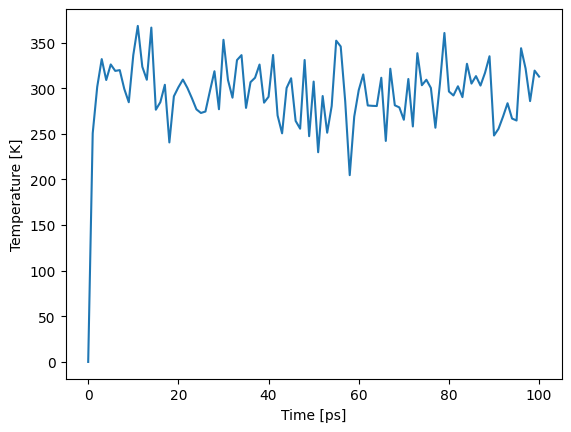

In [30]:
plt.plot(job5.output.steps*1e-3, job5.output.temperature)
plt.xlabel("Time [ps]")
plt.ylabel("Temperature [K]");